# Absolute structure assignment 
## from dynamical refinement against 3D electron diffraction data

27 July 2023

by Paul B. Klar, Department of Geosciences, University of Bremen

**Reference**:<br>Klar, P.B., Krysiak, Y., Xu, H. et al. Accurate structure models and absolute configuration determination using dynamical effects in continuous-rotation 3D electron diffraction data. Nat. Chem. 15, 848–855 (2023). https://doi.org/10.1038/s41557-023-01186-1

This notebook makes use specifically of the subsection **Absolute structure determination** of the Methods part in the reference. A visual introduction of the underlying approach is at the end of this notebook.

**Instructions**
1. Run a dynamical refinement of a chiral or polar crystal structure, i.e., a refinement in one of the 65 Sohncke space groups or in one of the polar space groups.
2. Run a dynamical refinement of the other enantiomorph. To do so, it is recommended to make a copy of the refinement of step 1, and change the enantiomorph using the option *Transformations* -> *Change enantiomorph*
3. For both refinements, there are now files jobname.m83 (together with .m40, .m42, .m50, .m90, .m95 files). Copy the path to the m83 files to the following cell. The run the subsequent cells.

In [4]:
# Define M83 files
# v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v v 

# M83 file of refinement of enantiomorph #1
#f1 = r"D:\ED_data_absXX\2022-LAL01\220503-08\reference_dynamical_refinement\5-L-alanine_3DED_dyn_refine_g2.1_ADP.m83"
f1 = r"D:\ED_data_absXX\2022-LAL01\220503-05\L-alanine_dynamical\IDP.m83"

# M83 file of refinement of enantiomorph #2
#f2 = r"D:\ED_data_absXX\2022-LAL01\220503-08\reference_dynamical_refinement\5-L-alanine_3DED_dyn_refine_g2.1_ADP_INV.m83"
f2 = r"D:\ED_data_absXX\2022-LAL01\220503-05\L-alanine_dynamical\IDP_INV.m83"

#### ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^
Change the path to the M83 files in the cell above.

### Import modules and define relevant functions

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

def calcZP(df1, df2, selector=...):
    """ calculate Z score and related parameters.
    If z > 0, then the probability that the refinement corresponding to df1
    corresponds to the correct enantiomorph is p.
    
    Here, uncertainties of Io have no influence on the calculation of z.
    """    
    # N reflections in comparison
    if selector is ...:
        N = len(df1["DeltaI"])
    else:
        N = np.count_nonzero( selector )
    if N == 0:
        return float("NaN"), float("NaN"), 0, 0
    
    # k reflections are better fitted with refinement of df1
    k = np.count_nonzero( np.abs(df1["DeltaI"][selector]) < np.abs(df2["DeltaI"][selector]) )
    
    # z-score
    z = (k-N/2) / (math.sqrt(N)/2)
    
    # associated probability for correct assignment
    # p = Phi(z) = cumulative distribution function of standard normal distribution
    p = 0.5+0.5*math.erf(z/math.sqrt(2))
    return z, p, N, k


def calcWZP(df1, df2, selector=...):
    """
    Here, the uncertainties Isigma are used.
    Currently, it is not recommended to use this approach for limiting cases
    without further investigations of the methodology. (Work in progress.)
    """
    # N reflections in comparison
    if selector is ...:
        N = len(df1["DeltaI"])
    else:
        N = np.count_nonzero( selector )
    if N == 0: # bad selector
        return float("NaN"), float("NaN"), 0, 0
    DeltaIby2S = np.abs(df1["DeltaI"][selector] - df2["DeltaI"][selector])/(2*df1["Isigma"][selector])
    
    # w reflections that are likely to 
    w = np.sum([ 0.5-0.5*math.erf( DI2S/math.sqrt(2) ) for DI2S in DeltaIby2S ])
    
    # k reflections are better fitted with refinement of df1
    k = np.count_nonzero( np.abs(df1["DeltaI"][selector]) < np.abs(df2["DeltaI"][selector]) )
    
    # z-score corrected for w
    z = (k-N/2) / (math.sqrt(N-w)/2)
    
    # associated probability 
    p = 0.5+0.5*math.erf(z/math.sqrt(2))
    return z, p, N, k, w


def calcRall(df, selector=...):
    """ Conventional R factor
    selector: ... takes all data (no reflections filtered out)
    """
    if selector is not ... and np.count_nonzero( selector ) == 0: # bad selector
        print("Bad selector")
        return -1
    else: # R factor for selected subset
        return np.sum(np.abs(df["DeltaF"][selector]))/np.sum(np.abs(df["Fo"][selector]))

    
def read_m83(file):
    """ read Jana2006 or Jana2020 m83 file 
    returns a dictionary with
    h, k, l: integer Miller indices of reflection hkl
    Ic:      calculated intensity from refinement
    Io:      observed (measured) intensity from data reduction
    Isigma:  uncertainty of measured intensity Io from data reduction
    
    Fc, Fo, Fsigma are the corresponding values based on the square root of the intensity
    In the M83 file, these values are provided with limited precision. Therefore, they
    are calculated from Ic, Io, and Isigma.
    
    FrameID: ID of (virtual) frame used in the dynamical refinement
    BlockID: only relevant for multi-block refinements against multiple data sets
    """
    # read lines
    with open(file, "r") as fh:
        Lines = fh.readlines()
    if not Lines:
        return False
    
    # check if m83 file is from a dynamical refinement
    dynamical = False
    Line = Lines[0].split()
    if sum([ float(e) for e in Line[13:16]]) == 0: # check sum of A,B, which is only defined in kinematical refinement
        dynamical = True
        print("M83 file from dynamical refinement")
    elif Line[-1] == '0' and len(Lines[0]) in (150,165):
        dynamical = False
        print("M83 file from kinematical refinement")
    else:
        print("Unknown M83 format")
        print(Lines[0])
        print(Line)
        print("Line length (Python):", len(Lines[0]))
        
    # Prepare dictionary
    m83data = dict()
    for key in "h k l Ic Io Isigma Fc Fo Fsigma FrameID BlockID".split():
        m83data[key] = []
    
    # Read each line
    for Line in Lines:
        BlockID = 1
        if dynamical:
            FrameID = Line.split()[-1]
            if "%" in FrameID:
                FrameID, BlockID = Zone.split("%")
        else:
            FrameID = -1
        m83data["BlockID"].append(int(BlockID))
        m83data["FrameID"].append(int(FrameID))

        # First three columns
        h,k,l = [ int(i) for i in Line[:12].split() ]
        m83data["h"].append(h)
        m83data["k"].append(k)
        m83data["l"].append(l)

        # Next three columns
        Ic = float(Line[14:27])
        Io = float(Line[29:42])
        Isigma = float(Line[45:57])
        m83data["Ic"].append(Ic) # Ic column is before Io column
        m83data["Io"].append(Io)  
        m83data["Isigma"].append(Isigma)

        # Calculate "structure factor amplitudes"
        if Io < 0.01*Isigma: # weak and negative intensities
            Fo = 0 if Io < 0 else math.sqrt(Io)
            Fsigma = 5*math.sqrt(Isigma) # this approach is how Jana treats weak reflections.
        else:
            Fo = math.sqrt(Io)
            Fsigma = Isigma/(2*Fo)
        m83data["Fc"].append(math.sqrt(Ic))
        m83data["Fo"].append(Fo)
        m83data["Fsigma"].append(Fsigma)
        
    return m83data

### Read in files from refinement

In [6]:
# Read in data from M83 files
# Pandas data frame
print(f1)
m83df = pd.DataFrame(data=read_m83(f1))
print(f2)
m83dfINV = pd.DataFrame(data=read_m83(f2))

if np.all((m83df['h'] == m83dfINV['h']) & (m83df['Io'] == m83dfINV['Io'])):
    print("M83 files are compatible.")
else:
    print("M83 files are not compatible!")
    input("...")

# Define differences Io-Ic and Fo-Fc
# Iobs - Icalc
m83df["DeltaI"] = m83df["Io"] - m83df["Ic"]
m83dfINV["DeltaI"] = m83dfINV["Io"] - m83dfINV["Ic"]

# Fobs - Fcalc
m83df["DeltaF"] = m83df["Fo"] - m83df["Fc"]
m83dfINV["DeltaF"] = m83dfINV["Fo"] - m83dfINV["Fc"]


# OPTIONAL:
# Read M42 file, especially for orientation matrix and unit cell parameters
fm42 = Path(f1).with_suffix(".m42")

if fm42.exists():
    print()
    print("M42 file header")
    with open(fm42, "r") as fh:
        print(fm42)
        m42_lines = fh.readlines()

        for i in range(15): # print header lines          
            print(m42_lines[i], end="")

        # orientation matrix
        OM = list()
        for i in range(5,8):
            OM.append( [ float(e) for e in m42_lines[i].split() ] )
        OM = np.array(OM)

    HKL = np.array(
        [ m83df[h].to_numpy() for h in "hkl"]
         ).transpose()

    # calculate |g| = d* for all reflections
    xyz_cartesian = np.matmul( HKL, OM.transpose())
    dstar = np.linalg.norm(xyz_cartesian, axis=1)
    
    m83df["dstar"] = dstar
    m83dfINV["dstar"] = dstar

# Overview on first two rows of Pandas data frame
#m83dfINV[:2]
m83df[:2]

D:\ED_data_absXX\2022-LAL01\220503-05\L-alanine_dynamical\IDP.m83
M83 file from dynamical refinement
D:\ED_data_absXX\2022-LAL01\220503-05\L-alanine_dynamical\IDP_INV.m83
M83 file from dynamical refinement
M83 files are compatible.

M42 file header
D:\ED_data_absXX\2022-LAL01\220503-05\L-alanine_dynamical\IDP.m42
commands
calcdyn 1 usewks 0 scalefc 0 usetwver 0
threads 8 tiltcorr 1 iedt 1
nzones 38 intsteps 60
ormat
   -0.121240    0.114940    0.015390
    0.120540    0.119880   -0.000430
   -0.023990    0.021490   -0.079940
omega 0 gmax 1.6 sgmax 0.01 sgmaxr 0.1 csgmaxr 0.7 dsgmin 0.0015
end
*******************************************************************************
# Zone 1 15.3007
-1.000000-0.589100-0.695800-36.69200-0.242000 1.500000      T   1
 2602.525 859.5044 0.000000 0.000000                        1100
 0.000000 0.000000                                          00


,h,k,l,Ic,Io,Isigma,Fc,Fo,Fsigma,FrameID,BlockID,DeltaI,DeltaF,dstar
0,-7,-2,11,905.36,1350.2,128.9,30.089201,36.745068,1.753977,1,1,444.84,6.655867,1.540948
1,-7,1,9,825.82,977.9,132.6,28.737084,31.271393,2.120149,1,1,152.08,2.534309,1.423124


### Calculate z-score and related parameters

In [7]:
Blocks = set(m83df["BlockID"])
print("Block       N       k     N-k       z    p(#1)   Rall(#1)  Rall(#2)")

for Block in Blocks:
    Selector = (m83df["BlockID"]==Block)
    z, p, N, k = calcZP(m83df, m83dfINV, Selector)
    print(f"{Block:5d}{N:8d}{k:8d}{N-k:8d}{z:7.1f}σ{p*100:8.1f}% {calcRall(m83df,Selector):10.4f}{calcRall(m83dfINV,Selector):10.4f}")

# For multiblock data, that means if there are several data sets in the same refinement
if len(Blocks)>1:
    z, p, N, k = calcZP(m83df, m83dfINV)
    Rall = np.sum(np.abs(m83df["DeltaF"]))/np.sum(np.abs(m83df["Fo"]))
    RallINV = np.sum(np.abs(m83dfINV["DeltaF"]))/np.sum(np.abs(m83dfINV["Fo"]))
    print(f"comb.{N:8d}{k:8d}{N-k:8d}{z:7.1f}σ{p*100:8.1f}% {Rall:10.4f}{RallINV:10.4f}") # {p*100:10.6f}% 

Block       N       k     N-k       z    p(#1)   Rall(#1)  Rall(#2)
    1    2860    1515    1345    3.2σ    99.9%     0.1360    0.1478


#### ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^
That is the data we are interested in.

- N: number of reflections in refinement
- k: number of reflections that fit better in refinement 1 in comparison to refinement 2.
- z: z-score
- p: probability for correct absolute structure assignment.
- Rall: R factors of refinement #1 and #2

The checked hypothesis is actually: "The observed preference for enantiomorph #1 is due to statistical errors." We then reject this hypothesis at a confidence level of *z*σ with a corresponding probability *p*.

$z(k,N) = \frac{ k-N/2}{\sqrt{N}/2} = \frac{ 2k-N}{\sqrt{N}}$

$p(z) = \Phi(z) = \frac{1}{2}[1+\text{erf}({\frac{z}{\sqrt{2}})}]$

## Introduction to hypothesis testing
We have two refinements, #1 and #2, each against the same set of measured reflections. If we assume that a better match of #1 or #2 is the result of purely random errors, then the probability that a reflection **h** better matches #1 or #2 is 50%. The probability distribution "k of N reflections fit better to #1" is given by the binomial distribution:

$p( k ) = \left( {\begin{array}{*{20}{c}} N \\ k \end{array}} \right)2^{ - N}$

Let's plot that for N = 100:

p(k=  0) = 0.000%
p(k= 10) = 0.000%
p(k= 20) = 0.000%
p(k= 30) = 0.002%
p(k= 40) = 1.084%
p(k= 50) = 7.959%
p(k= 60) = 1.084%
p(k= 70) = 0.002%
p(k= 80) = 0.000%
p(k= 90) = 0.000%
p(k=100) = 0.000%


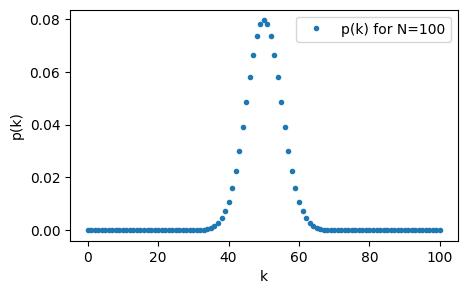

In [11]:
N = 100
k_range = range(0,N+1)
p_of_k = []
for k in k_range:
    p = math.comb(N,k)*2**(-N)
    p_of_k.append(p)
    if k%(int(N/10)) == 0:
        print(f"p(k={k:>3d}) = {p*100:5.3f}%")
    
fig, ax = plt.subplots(figsize=(5,3))    
ax.plot(k_range, p_of_k,".", label=f"p(k) for N={N}")
ax.set_xlabel("k")
ax.set_ylabel("p(k)")
ax.legend()
plt.show()

The sum of all probablities is 100%:

In [14]:
sum(p_of_k)

1.0000000000000002

The probability to have between 40 and 60 reflections favoring #1 is:

In [15]:
sum(p_of_k[40:61])

0.9647997997822952

This distribution gives us the probability to find k reflections better fitting to #1 based on the assumption that any preference for #1 or #2 is due to random errors. As expected, the probability is highest for k = N/2.

The probability distribution function can be well approximated by a Gaussian with expectation value $\mu_0 = N/2$ and variance $\sigma^2 = \frac{1}{4}N$

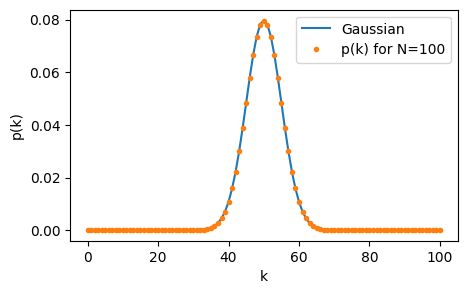

In [16]:
N = 100

fig, ax = plt.subplots(figsize=(5,3))

# Gaussian
Mu = N/2
Sigma = math.sqrt(N)/2
x = np.linspace(0, N, N+1)
y = 1/(Sigma*math.sqrt(2*math.pi)) * np.exp( -0.5*( (x-Mu)/Sigma )**2 ) # normal distribution

ax.plot(x, y, "-", label="Gaussian")

# binomial distribution
if N < 1024:
    k_range = range(0,N+1)
    p_of_k = []
    for k in k_range:
        p = math.comb(N,k)*2**(-N)
        p_of_k.append(p)

    ax.plot(k_range, p_of_k, ".", label=f"p(k) for N={N}")
else:
    print("N too large for calculating p(k).")

ax.set_xlabel("k")
ax.set_ylabel("p(k)")
ax.legend()

plt.show()

For a given N we can thus easily calculate the probability that k is a sample of this distribution.
The cumulative distribution function tells us, how likely it is to obtain a value less or equal to k:

$p(z) = \Phi(z) = \frac{1}{2}[1+\text{erf}({\frac{z}{\sqrt{2}})}]$

where

$z = \frac{x-\mu_0}{\sigma} = \frac{k-N/2}{\sqrt{N/4}}$

If k was indeed randomly favoring #1 or #2, we expect that k is close to N/2, z will be close to 0, and p(z) will be close to 50%. If there are non-random errors so that one of the models fits better to the data, we get an estimate of how likely it is that #1 is the better model with the z-test. Here, the z-test estimates the likelihood that the observation of k is a result of random errors.

Following the empirical *68-95-99.7* rule, we may say that if $-3 \le z \le 3$, the absolute structure determination is not significant. This is the case if $N/2-3/2\sqrt{N} \le k \le N/2+3/2\sqrt{N}$. If k is outside that range, the z-test yields a significant result and we may reject the hypothesis that the preference for #1 or #2 is a result of random errors.

### Example:
For a refinement of alanine, there are N=3481 reflections. k=1941 reflections fit better if the modelled enantiomorph contained molecules of L-alanin, in contrast to (N-k)=1540 reflections fitting better to a model of D-alanin.

In [17]:
N=3481 # reflections
k=1941 # reflections matching better #1

zz = (2*k-N)/math.sqrt(N)
pp = 0.5+0.5*math.erf(zz/math.sqrt(2))

print(f"z: {zz:8.4f}")
print(f"p: {pp*100:8.4f}%")

z:   6.7966
p: 100.0000%


If we plot the probability distribution function like above, we can plot a point for our obtained k (or associated z-score):

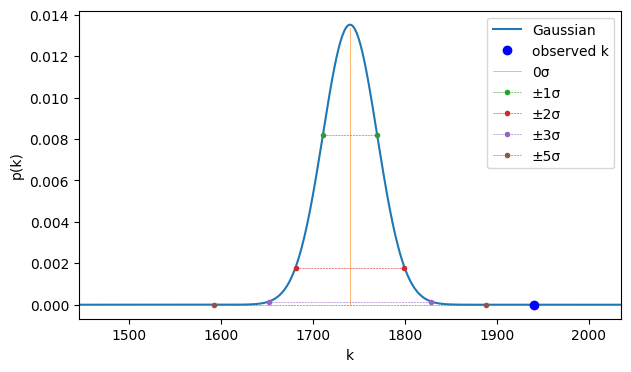

In [18]:
N=3481 # reflections
k=1941 # reflectionsmatching better #1

zz = (2*k-N)/math.sqrt(N)

fig, ax = plt.subplots(figsize=(7,4))

# binomial distribution (assuming p(reflection favors #1) is 50%)
Mu = N/2
Sigma = math.sqrt(N)/2
x = np.linspace(0, N, N+1)
y = 1/(Sigma*math.sqrt(2*math.pi)) * np.exp( -0.5*( (x-Mu)/Sigma )**2 ) # normal distribution

peak = max(y) # = 1/math.sqrt(2*math.pi*Sigma*Sigma)

ax.plot(x, y, "-", label="Gaussian")
ax.plot([k], [0], "o", label="observed k", c="blue")

plt.plot( [Mu, Mu],[0,peak*0.99], linewidth=0.4, label="0σ")
plt.plot( [Mu-Sigma, Mu+Sigma],[peak*0.607,peak*0.607], "--.", linewidth=0.4, label="±1σ")
plt.plot( [Mu-2*Sigma, Mu+2*Sigma],[peak*0.131,peak*0.131], "--.", linewidth=0.4, label="±2σ")
plt.plot( [Mu-3*Sigma, Mu+3*Sigma],[peak*0.011,peak*0.011], "--.", linewidth=0.4, label="±3σ")
plt.plot( [Mu-5*Sigma, Mu+5*Sigma],[0,0], "--.", linewidth=0.4, label="±5σ")

#plt.plot( [Mu-5*Sigma, Mu-5*Sigma],[0,peak/6], "-", c="orange", linewidth=0.6, label="±5σ")
#plt.plot( [Mu+5*Sigma, Mu+5*Sigma],[0,peak/6], "-", c="orange", linewidth=0.6)

ax.set_xlabel("k")
ax.set_ylabel("p(k)")

ax.set_xlim(Mu-10*Sigma, Mu+10*Sigma)
ax.legend()

plt.show()

If we assigned the wrong absolute structure and #2 fits better than #1, we get negative z scores and a probability below 50%:

In [19]:
N=1000 # reflections
k=480  # reflections matching better #1

if k < N/2:
    print("k is less than N/2")

zz = (2*k-N)/math.sqrt(N)
pp = 0.5+0.5*math.erf(zz/math.sqrt(2))

print(f"z: {zz:8.4f}")
print(f"p: {pp*100:8.4f}%")

k is less than N/2
z:  -1.2649
p:  10.2952%


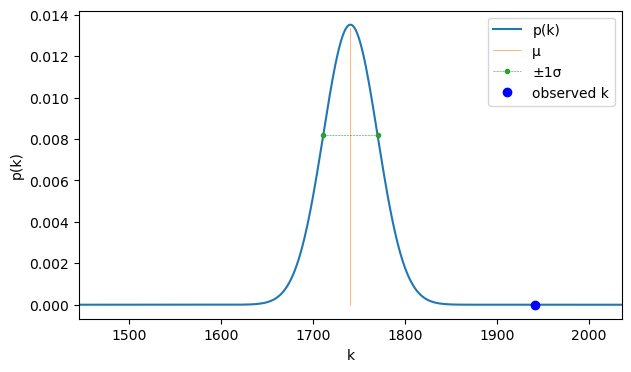

In [5]:
N=3481 # reflections
k=1941 # reflectionsmatching better #1

zz = (2*k-N)/math.sqrt(N)

fig, ax = plt.subplots(figsize=(7,4))

# binomial distribution (assuming p(reflection favors #1) is 50%)
Mu = N/2
Sigma = math.sqrt(N)/2
x = np.linspace(0, N, N+1)
y = 1/(Sigma*math.sqrt(2*math.pi)) * np.exp( -0.5*( (x-Mu)/Sigma )**2 ) # normal distribution

peak = max(y) # = 1/math.sqrt(2*math.pi*Sigma*Sigma)

ax.plot(x, y, "-", label="p(k)")
plt.plot( [Mu, Mu],[0,peak*0.99], linewidth=0.4, label="µ")
plt.plot( [Mu-Sigma, Mu+Sigma],[peak*0.607,peak*0.607], "--.", linewidth=0.4, label="±1σ")

ax.plot([k], [0], "o", label="observed k", c="blue")

ax.set_xlabel("k")
ax.set_ylabel("p(k)")

ax.set_xlim(Mu-10*Sigma, Mu+10*Sigma)
ax.legend()

plt.show()

... end of Jupyter notebook